# E-commerce Sales and Customer Behavior Analysis

**Dataset used:** Brazilian E-Commerce Public Dataset by Olist  

This project analyzes an e-commerce dataset in order to understand sales patterns, customer behavior, product performance, and payment behavior.

The dataset contains information about orders, customers, products, order items, and payments. The analysis focuses only on delivered orders, because these orders represent completed transactions and are more reliable for studying actual sales performance.

The project uses Python libraries such as pandas, matplotlib, and seaborn for data loading, cleaning, manipulation, aggregation, and visualization.

## 1. Introduction

E-commerce platforms generate large amounts of data about orders, customers, products, and payments. Analyzing this data can help understand which product categories perform better, how sales change over time, and how customers complete their purchases.

The objective of this project is to explore an e-commerce dataset and identify patterns related to sales performance and customer payment behavior.

The analysis focuses on delivered orders because they represent completed transactions. Cancelled or unavailable orders are excluded from the main analysis to avoid mixing incomplete transactions with successful sales.

### Research Questions

**Main question:**  
How do product categories, time, and payment behavior relate to sales performance in delivered e-commerce orders?

**Sub-question 1:**  
Which product categories generate the highest total revenue?

**Sub-question 2:**  
How does the average order value change over time?

**Sub-question 3:**  
Is there a relationship between total payment value and the number of payment records per order?

**Sub-question 4:**  
Are there customers who appear more than once in the dataset, and how can repeat orders be identified correctly?

### Data Dictionary

The project uses several related CSV files. The most important variables are listed below.

| Dataset | Column | Description |
|---|---|---|
| orders | order_id | Unique identifier of each order |
| orders | customer_id | Customer identifier linked to each order |
| orders | order_status | Status of the order, such as delivered, shipped, cancelled, or unavailable |
| orders | order_purchase_timestamp | Date and time when the order was placed |
| customers | customer_id | Identifier used to connect customers with orders |
| customers | customer_unique_id | Unique customer identifier, useful for identifying repeat customers |
| customers | customer_city | City of the customer |
| customers | customer_state | State of the customer |
| order_items | order_id | Identifier used to connect order items with orders |
| order_items | product_id | Identifier of the purchased product |
| order_items | price | Price of the product item |
| order_items | freight_value | Shipping cost of the item |
| products | product_id | Identifier used to connect products with order items |
| products | product_category_name | Product category name |
| payments | order_id | Identifier used to connect payments with orders |
| payments | payment_type | Type of payment used by the customer |
| payments | payment_installments | Number of payment installments |
| payments | payment_value | Value of the payment |

## 2. Setup and Data Loading

In this section, I import the Python libraries needed for data analysis and load the CSV files used in the project.

The main libraries are:

- `pandas` for reading, cleaning, merging, and aggregating data
- `matplotlib` for creating plots
- `seaborn` for more readable statistical visualizations

In [1]:
# Import pandas for data loading, cleaning, merging, and aggregation
import pandas as pd

# Import matplotlib for creating plots
import matplotlib.pyplot as plt

# Import seaborn for more readable visualizations
import seaborn as sns

# Make plots appear with a clear default size
plt.rcParams["figure.figsize"] = (10, 5)

# Display more columns when viewing DataFrames
pd.set_option("display.max_columns", 50)

In [2]:
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")

In [3]:
# Store all loaded datasets in a dictionary to check them together
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "payments": payments
}

# Print the shape of each dataset
for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} rows and {df.shape[1]} columns")

customers: 99441 rows and 5 columns
orders: 99441 rows and 8 columns
order_items: 112650 rows and 7 columns
products: 32951 rows and 9 columns
payments: 103886 rows and 5 columns


## 3. Initial Exploration

In this section, I explore the structure and quality of the datasets before cleaning them.

The goal is to understand:

- the number of rows and columns in each dataset
- the data types of the columns
- the presence of missing values
- the presence of duplicated rows
- the distribution of order statuses

This step is important because data cleaning decisions should be based on the actual structure and quality of the data.

In [4]:
# Display the first five rows of each dataset
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    display(df.head())


CUSTOMERS


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



ORDERS


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



ORDER_ITEMS


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



PRODUCTS


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0



PAYMENTS


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [5]:
# Display the last five rows of each dataset
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    display(df.tail())


CUSTOMERS


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS
99440,274fa6071e5e17fe303b9748641082c8,84732c5050c01db9b23e19ba39899398,6703,cotia,SP



ORDERS


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00
99440,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-08 20:57:30,2018-03-09 11:20:28,2018-03-09 22:11:59,2018-03-16 13:08:30,2018-04-03 00:00:00



ORDER_ITEMS


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72
112649,fffe41c64501cc87c801fd61db3f6244,1,350688d9dc1e75ff97be326363655e01,f7ccf836d21b2fb1de37564105216cc1,2018-06-12 17:10:13,43.00,12.79



PRODUCTS


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0
32950,106392145fca363410d287a815be6de4,cama_mesa_banho,58.0,309.0,1.0,2083.0,12.0,2.0,7.0



PAYMENTS


,order_id,payment_sequential,payment_type,payment_installments,payment_value
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54
103885,28bbae6599b09d39ca406b747b6632b1,1,boleto,1,191.58


In [6]:
# Check column names and data types for each dataset
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(df.info())


CUSTOMERS
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB
None

ORDERS
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approv

In [7]:
# Generate summary statistics for each dataset
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    display(df.describe(include="all"))


CUSTOMERS


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN



ORDERS


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522



ORDER_ITEMS


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2018-03-01 02:50:48,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000



PRODUCTS


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,1e9e8ef04dbcff4541ed26657ea517e5,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000



PAYMENTS


,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500


In [8]:
# Check missing values in each dataset
for name, df in datasets.items():
    print(f"\n{name.upper()} - Missing Values")
    missing_values = df.isna().sum()
    missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
    
    if len(missing_values) == 0:
        print("No missing values found.")
    else:
        display(missing_values)


CUSTOMERS - Missing Values
No missing values found.

ORDERS - Missing Values


order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
dtype: int64


ORDER_ITEMS - Missing Values
No missing values found.

PRODUCTS - Missing Values


product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


PAYMENTS - Missing Values
No missing values found.


In [9]:
# Check duplicated rows in each dataset
for name, df in datasets.items():
    duplicated_count = df.duplicated().sum()
    print(f"{name}: {duplicated_count} duplicated rows")

customers: 0 duplicated rows
orders: 0 duplicated rows
order_items: 0 duplicated rows
products: 0 duplicated rows
payments: 0 duplicated rows


In [10]:
# Check the distribution of order statuses
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

The order status distribution shows that the dataset contains different types of orders, including delivered, shipped, cancelled, and unavailable orders.

For the main analysis, I focus only on delivered orders because they represent completed transactions. This makes the analysis more reliable for studying actual sales performance.

## 4. Data Cleaning and Feature Extraction

In this section, I clean the datasets and prepare them for analysis.

The main cleaning steps are:

- filtering the orders dataset to keep only delivered orders
- removing duplicated rows
- converting date columns into datetime format
- extracting year and month from the order purchase date
- aggregating payment information at the order level
- saving cleaned datasets for later analysis

In [11]:
# Keep only delivered orders for the main analysis
orders_delivered = orders[orders["order_status"] == "delivered"].copy()

# Check the shape before and after filtering
print("Original orders shape:", orders.shape)
print("Delivered orders shape:", orders_delivered.shape)

Original orders shape: (99441, 8)
Delivered orders shape: (96478, 8)


The duplicate check showed that there were no duplicated rows in the original datasets. However, I still applied `drop_duplicates()` as a safe cleaning step and created cleaned copies of the datasets. This makes the workflow more consistent and ensures that the following analysis uses cleaned DataFrames.

In [12]:
# Create cleaned copies of the datasets
# No duplicated rows were found in the initial exploration,
# but drop_duplicates() is still applied as a safe cleaning step.

customers_cleaned = customers.drop_duplicates().copy()
orders_cleaned = orders_delivered.drop_duplicates().copy()
order_items_cleaned = order_items.drop_duplicates().copy()
products_cleaned = products.drop_duplicates().copy()
payments_cleaned = payments.drop_duplicates().copy()

# Store cleaned datasets in a dictionary
cleaned_datasets = {
    "customers_cleaned": customers_cleaned,
    "orders_cleaned": orders_cleaned,
    "order_items_cleaned": order_items_cleaned,
    "products_cleaned": products_cleaned,
    "payments_cleaned": payments_cleaned
}

# Check the shape of cleaned datasets
for name, df in cleaned_datasets.items():
    print(f"{name}: {df.shape[0]} rows and {df.shape[1]} columns")

customers_cleaned: 99441 rows and 5 columns
orders_cleaned: 96478 rows and 8 columns
order_items_cleaned: 112650 rows and 7 columns
products_cleaned: 32951 rows and 9 columns
payments_cleaned: 103886 rows and 5 columns


In [13]:
# Convert date columns in the orders dataset to datetime format
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders_cleaned[col] = pd.to_datetime(orders_cleaned[col], errors="coerce")

# Check the updated data types
orders_cleaned[date_columns].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [14]:
# Extract year and month from the order purchase date
orders_cleaned["purchase_year"] = orders_cleaned["order_purchase_timestamp"].dt.year
orders_cleaned["purchase_month"] = orders_cleaned["order_purchase_timestamp"].dt.month

# Display the new columns
orders_cleaned[["order_id", "order_purchase_timestamp", "purchase_year", "purchase_month"]].head()

,order_id,order_purchase_timestamp,purchase_year,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017,10
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018,7
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018,8
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017,11
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018,2


In [15]:
# Aggregate payment information at the order level
payment_summary = payments_cleaned.groupby("order_id").agg(
    total_payment_value=("payment_value", "sum"),
    number_of_payment_records=("payment_value", "count"),
    average_installments=("payment_installments", "mean")
).reset_index()

payment_summary.head()

,order_id,total_payment_value,number_of_payment_records,average_installments
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1,2.0
1,00018f77f2f0320c557190d7a144bdd3,259.83,1,3.0
2,000229ec398224ef6ca0657da4fc703e,216.87,1,5.0
3,00024acbcdf0a6daa1e931b038114c75,25.78,1,2.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1,3.0


In [16]:
payment_summary["number_of_payment_records"].value_counts().sort_index()

number_of_payment_records
1     96479
2      2382
3       301
4       108
5        52
6        36
7        28
8        11
9         9
10        5
11        8
12        8
13        3
14        2
15        2
19        2
21        1
22        1
26        1
29        1
Name: count, dtype: int64

The payment data was aggregated at the order level using `order_id`. For each order, I calculated the total payment value, the number of payment records, and the average number of installments.

This step is important because one order can have more than one payment record. By aggregating payments before merging with the orders dataset, I avoid duplicating order rows in the final analytical dataset.

In [17]:
# Merge delivered orders with customer information
orders_customers = orders_cleaned.merge(
    customers_cleaned,
    on="customer_id",
    how="left"
)

# Merge the result with aggregated payment information
orders_customers_payments = orders_customers.merge(
    payment_summary,
    on="order_id",
    how="left"
)

# Check the final analytical dataset
print("orders_customers_payments shape:", orders_customers_payments.shape)
orders_customers_payments.head()

orders_customers_payments shape: (96478, 17)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_payment_value,number_of_payment_records,average_installments
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,3.0,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,1.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,1.0,3.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,1.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,1.0,1.0


In [18]:
# Check missing values after merging orders, customers, and payments
orders_customers_payments.isna().sum().sort_values(ascending=False).head(15)

order_approved_at                14
order_delivered_customer_date     8
order_delivered_carrier_date      2
average_installments              1
number_of_payment_records         1
total_payment_value               1
order_id                          0
order_purchase_timestamp          0
customer_id                       0
purchase_year                     0
order_estimated_delivery_date     0
order_status                      0
purchase_month                    0
customer_city                     0
customer_zip_code_prefix          0
dtype: int64

In [19]:
# Inspect delivered orders with missing payment information
orders_customers_payments[
    orders_customers_payments["total_payment_value"].isna()
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_payment_value,number_of_payment_records,average_installments
29811,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,2016,9,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,NaN,NaN,NaN


In [20]:
# Create a payment-complete dataset for payment-related analysis
orders_payment_complete = orders_customers_payments.dropna(
    subset=["total_payment_value"]
).copy()

print("Original merged dataset:", orders_customers_payments.shape)
print("Payment-complete dataset:", orders_payment_complete.shape)

Original merged dataset: (96478, 17)
Payment-complete dataset: (96477, 17)


The missing value check after merging shows that only a small number of values are missing.

Some delivered orders have missing approval or delivery date information. This is likely a data quality issue in the original dataset. Since the main time-based analysis uses `order_purchase_timestamp`, `purchase_year`, and `purchase_month`, these missing delivery-related dates do not affect the main analysis.

Only one delivered order has missing payment information. For payment-related analysis, this row can be excluded by creating a payment-complete dataset.

In [21]:
# Define a custom function to classify orders based on total payment value
def classify_order_value(value):
    if pd.isna(value):
        return "Unknown"
    elif value < 50:
        return "Low"
    elif value < 150:
        return "Medium"
    else:
        return "High"

# Apply the function to create a new column
orders_customers_payments["order_value_category"] = (
    orders_customers_payments["total_payment_value"].apply(classify_order_value)
)

# Check the result
orders_customers_payments[["order_id", "total_payment_value", "order_value_category"]].head()

,order_id,total_payment_value,order_value_category
0,e481f51cbdc54678b7cc49136f2d6af7,38.71,Low
1,53cdb2fc8bc7dce0b6741e2150273451,141.46,Medium
2,47770eb9100c2d0c44946d9cf07ec65d,179.12,High
3,949d5b44dbf5de918fe9c16f97b45f8a,72.20,Medium
4,ad21c59c0840e6cb83a9ceb5573f8159,28.62,Low


In [22]:
# Create a payment-complete dataset for payment-related analysis
orders_payment_complete = orders_customers_payments.dropna(
    subset=["total_payment_value"]
).copy()

print("Original merged dataset:", orders_customers_payments.shape)
print("Payment-complete dataset:", orders_payment_complete.shape)

Original merged dataset: (96478, 18)
Payment-complete dataset: (96477, 18)


In [23]:
# Save cleaned datasets in the processed data folder
from pathlib import Path

processed_folder = Path("../data/processed")
processed_folder.mkdir(parents=True, exist_ok=True)

customers_cleaned.to_csv(processed_folder / "customers_cleaned.csv", index=False)
orders_cleaned.to_csv(processed_folder / "orders_cleaned.csv", index=False)
payments_cleaned.to_csv(processed_folder / "payments_cleaned.csv", index=False)
orders_customers_payments.to_csv(processed_folder / "orders_customers_payments.csv", index=False)
orders_payment_complete.to_csv(processed_folder / "orders_payment_complete.csv", index=False)

print("Cleaned datasets were saved successfully in:", processed_folder)

Cleaned datasets were saved successfully in: ..\data\processed


After cleaning the data, the analysis focuses only on delivered orders. Duplicate rows were checked and cleaned copies of the datasets were created. Date columns were converted into datetime format, and new year and month columns were created from the purchase date.

Payment data was aggregated at the order level before merging. This step is important because one order can have more than one payment record. Aggregating payments first prevents duplicated order rows after merging.

After the merge, only one delivered order had missing payment information. For payment-related analysis, I created a payment-complete dataset called `orders_payment_complete`.

The cleaned datasets are now ready for analysis and visualization.

## 5. Analysis and Visualizations

In this section, I analyze the cleaned datasets to answer the research questions.

The analysis focuses on four main parts:

1. product category revenue
2. average order value over time
3. payment behavior
4. repeat customer behavior

The goal is not only to create tables and plots, but also to interpret what the results mean for e-commerce sales performance.

### 5.1 Product Category Revenue

This analysis answers the first research question:

**Which product categories generate the highest total revenue?**

To answer this question, I merge delivered orders with order items and product information. Then, I calculate the total product revenue for each product category.

In [24]:
# Keep only order items that belong to delivered orders
delivered_order_items = order_items_cleaned.merge(
    orders_cleaned[["order_id"]],
    on="order_id",
    how="inner"
)

# Merge delivered order items with product information
items_products_delivered = delivered_order_items.merge(
    products_cleaned[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

# Replace missing product categories with "Unknown"
items_products_delivered["product_category_name"] = (
    items_products_delivered["product_category_name"].fillna("Unknown")
)

# Calculate revenue by product category
product_revenue = (
    items_products_delivered
    .groupby("product_category_name")
    .agg(
        total_revenue=("price", "sum"),
        number_of_items_sold=("order_item_id", "count"),
        average_item_price=("price", "mean")
    )
    .reset_index()
    .sort_values(by="total_revenue", ascending=False)
)

# Display the top 10 product categories by revenue
top_10_product_revenue = product_revenue.head(10)
top_10_product_revenue

,product_category_name,total_revenue,number_of_items_sold,average_item_price
12,beleza_saude,1233131.72,9465,130.283330
67,relogios_presentes,1166176.98,5859,199.040276
14,cama_mesa_banho,1023434.76,10953,93.438762
33,esporte_lazer,954852.55,8431,113.254958
45,informatica_acessorios,888724.61,7644,116.264339
55,moveis_decoracao,711927.69,8160,87.246040
73,utilidades_domesticas,615628.69,6795,90.600249
27,cool_stuff,610204.10,3718,164.121598
9,automotivo,578966.65,4140,139.847017
13,brinquedos,471286.48,4030,116.944536


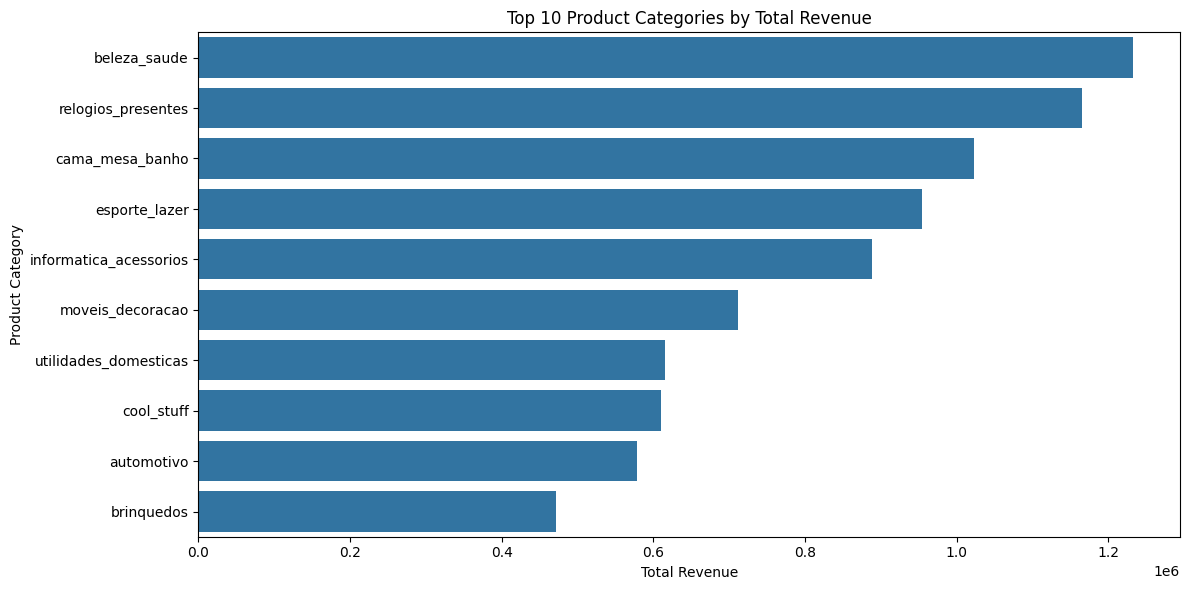

In [25]:
# Plot the top 10 product categories by total revenue
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_10_product_revenue,
    x="total_revenue",
    y="product_category_name"
)

plt.title("Top 10 Product Categories by Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

The bar chart shows that revenue is not equally distributed across all product categories. Some categories generate much higher total revenue than others.

This suggests that product category is an important factor for understanding sales performance in the e-commerce dataset.

### 5.2 Average Order Value Over Time

This analysis answers the second research question:

**How does the average order value change over time?**

To answer this question, I calculate the average total payment value for delivered orders by year and month. Since this analysis uses payment values, I use the payment-complete dataset.

In [26]:
# Create a monthly summary of average order value
monthly_order_value = (
    orders_payment_complete
    .groupby(["purchase_year", "purchase_month"])
    .agg(
        average_order_value=("total_payment_value", "mean"),
        number_of_orders=("order_id", "count")
    )
    .reset_index()
)

# Create a date column for easier plotting
monthly_order_value["purchase_period"] = pd.to_datetime(
    monthly_order_value["purchase_year"].astype(str) + "-" +
    monthly_order_value["purchase_month"].astype(str) + "-01"
)

# Sort by date
monthly_order_value = monthly_order_value.sort_values("purchase_period")

monthly_order_value.head()

,purchase_year,purchase_month,average_order_value,number_of_orders,purchase_period
0,2016,10,175.723434,265,2016-10-01
1,2016,12,19.620000,1,2016-12-01
2,2017,1,170.060893,750,2017-01-01
3,2017,2,164.125015,1653,2017-02-01
4,2017,3,162.753099,2546,2017-03-01


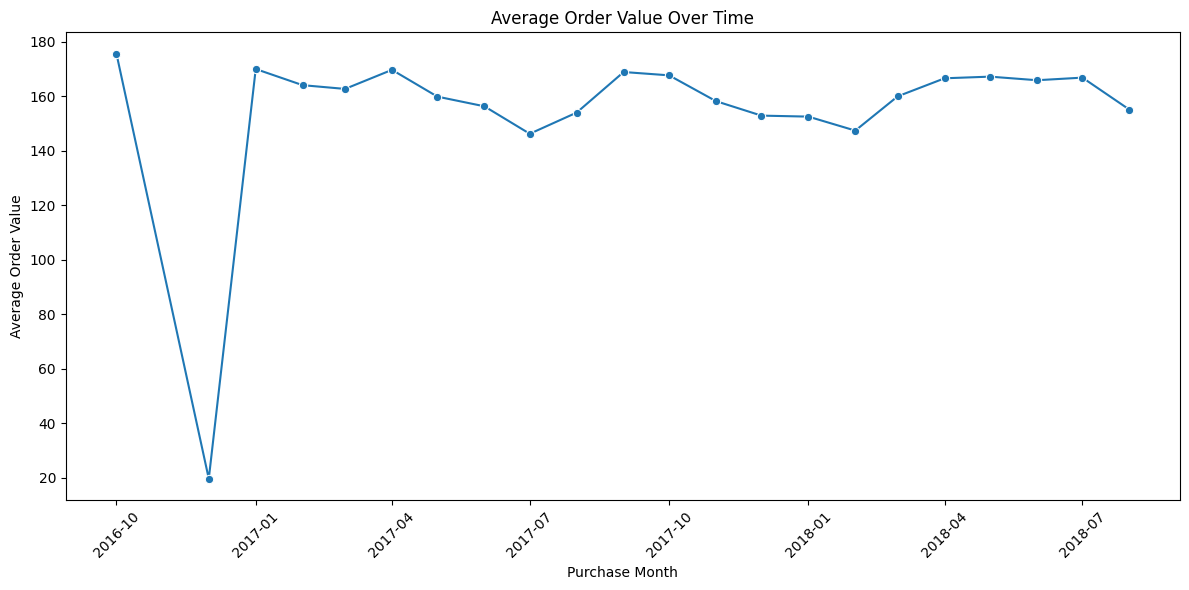

In [27]:
# Plot average order value over time
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_order_value,
    x="purchase_period",
    y="average_order_value",
    marker="o"
)

plt.title("Average Order Value Over Time")
plt.xlabel("Purchase Month")
plt.ylabel("Average Order Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

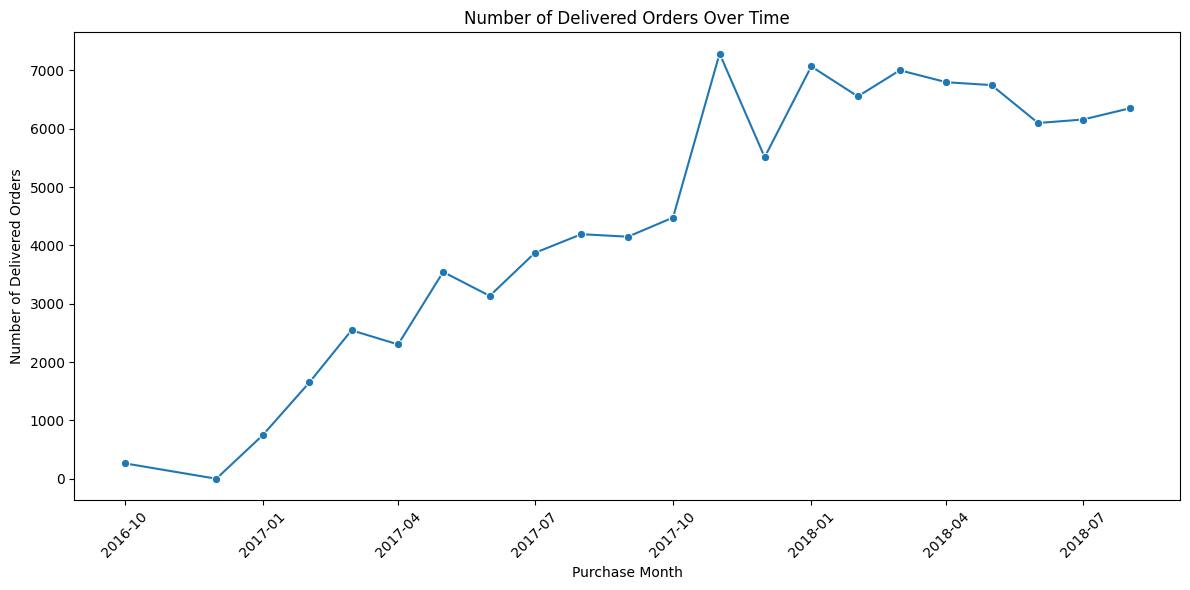

In [28]:
# Plot the number of delivered orders over time
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_order_value,
    x="purchase_period",
    y="number_of_orders",
    marker="o"
)

plt.title("Number of Delivered Orders Over Time")
plt.xlabel("Purchase Month")
plt.ylabel("Number of Delivered Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The time-based analysis shows how average order value and order volume changed across months.

Looking at both plots together is important because a high average order value does not always mean high total sales volume. A month can have expensive orders but a small number of orders.

### 5.3 Payment Behavior

This analysis answers the third research question:

**Is there a relationship between total payment value and the number of payment records per order?**

The goal is to understand whether orders with higher total payment values tend to have more payment records. Since this part directly uses payment information, I use the payment-complete dataset.

In [29]:
# Summary of payment behavior by order value category
payment_behavior_summary = (
    orders_payment_complete
    .groupby("order_value_category")
    .agg(
        number_of_orders=("order_id", "count"),
        average_payment_value=("total_payment_value", "mean"),
        average_number_of_payment_records=("number_of_payment_records", "mean"),
        average_installments=("average_installments", "mean")
    )
    .reset_index()
)

payment_behavior_summary

,order_value_category,number_of_orders,average_payment_value,average_number_of_payment_records,average_installments
0,High,31294,328.565116,1.041222,4.217865
1,Low,16451,36.876363,1.043219,1.514761
2,Medium,48732,93.033161,1.046745,2.545374


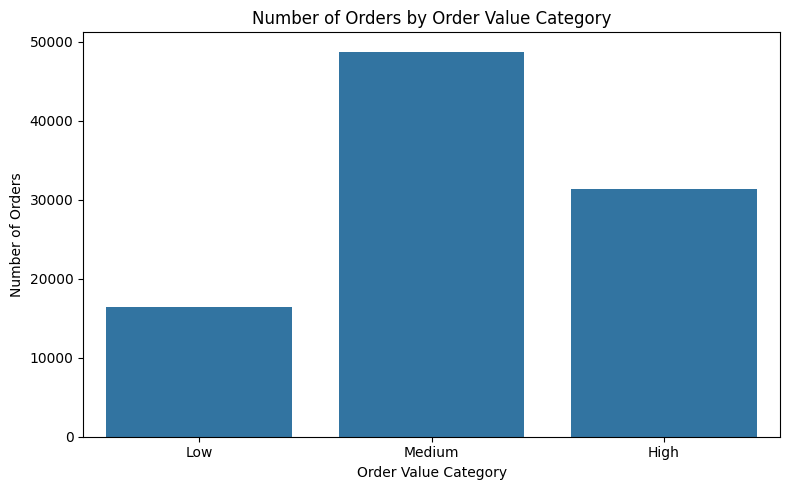

In [30]:
# Plot distribution of order value categories
plt.figure(figsize=(8, 5))

sns.countplot(
    data=orders_payment_complete,
    x="order_value_category",
    order=["Low", "Medium", "High"]
)

plt.title("Number of Orders by Order Value Category")
plt.xlabel("Order Value Category")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

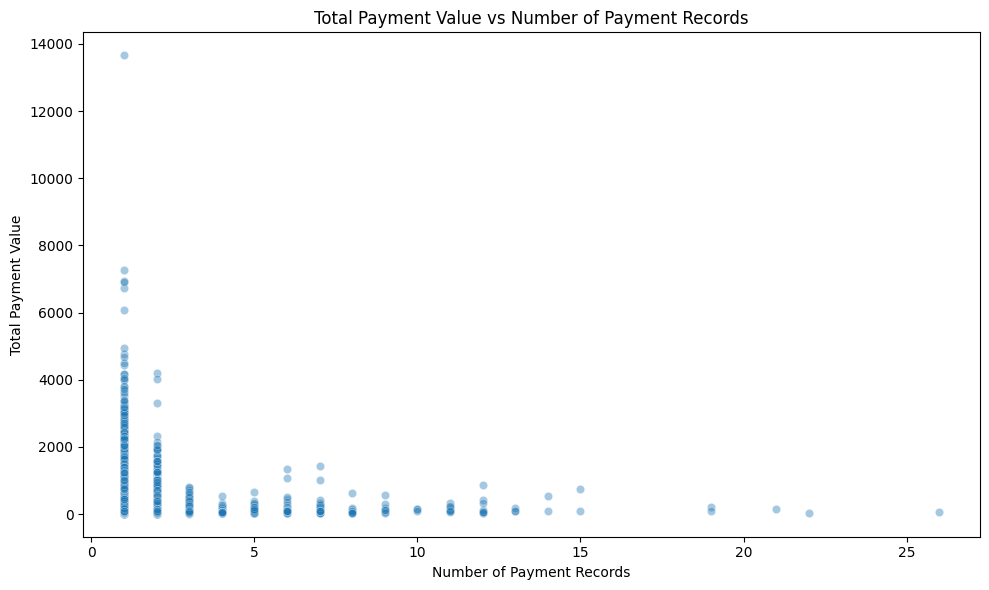

In [31]:
# Scatter plot of total payment value and number of payment records
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=orders_payment_complete,
    x="number_of_payment_records",
    y="total_payment_value",
    alpha=0.4
)

plt.title("Total Payment Value vs Number of Payment Records")
plt.xlabel("Number of Payment Records")
plt.ylabel("Total Payment Value")
plt.tight_layout()
plt.show()

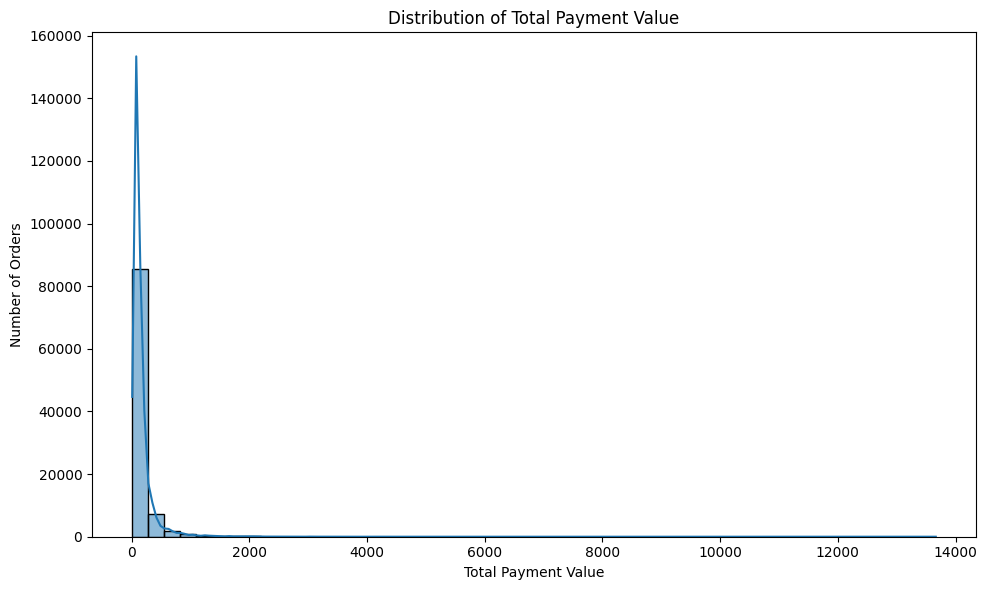

In [32]:
# Plot the distribution of total payment value
plt.figure(figsize=(10, 6))

sns.histplot(
    data=orders_payment_complete,
    x="total_payment_value",
    bins=50,
    kde=True
)

plt.title("Distribution of Total Payment Value")
plt.xlabel("Total Payment Value")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

The payment analysis shows that most orders are concentrated in lower or medium payment ranges, while very high-value orders are less frequent.

The scatter plot helps check whether orders with higher total payment values also have more payment records. This can be useful for understanding whether more expensive orders involve more complex payment behavior.

### 5.4 Repeat Customer Behavior

This analysis answers the fourth research question:

**Are there customers who appear more than once in the dataset, and how can repeat orders be identified correctly?**

In this dataset, `customer_unique_id` is more suitable than `customer_id` for identifying repeat customers, because `customer_id` is linked to individual orders while `customer_unique_id` represents the same customer across orders.

In [33]:
# Count the number of delivered orders for each unique customer
repeat_customers = (
    orders_customers_payments
    .groupby("customer_unique_id")
    .agg(
        number_of_orders=("order_id", "nunique"),
        total_customer_payment=("total_payment_value", "sum"),
        average_order_value=("total_payment_value", "mean")
    )
    .reset_index()
    .sort_values(by="number_of_orders", ascending=False)
)

repeat_customers.head(10)

,customer_unique_id,number_of_orders,total_customer_payment,average_order_value
51431,8d50f5eadf50201ccdcedfb9e2ac8455,15,879.27,58.618000
22779,3e43e6105506432c953e165fb2acf44c,9,1172.66,130.295556
36706,6469f99c1f9dfae7733b25662e7f1782,7,758.83,108.404286
10060,1b6c7548a2a1f9037c1fd3ddfed95f33,7,959.01,137.001429
73921,ca77025e7201e3b30c44b472ff346268,7,1122.72,160.388571
26257,47c1a3033b8b77b3ab6e109eb4d5fdf3,6,944.21,157.368333
80538,dc813062e0fc23409cd255f7f53c7074,6,1094.63,182.438333
36500,63cfc61cee11cbe306bff5857d00bfe4,6,826.32,137.720000
87885,f0e310a6839dce9de1638e0fe5ab282a,6,540.69,90.115000
6964,12f5d6e1cbf93dafd9dcc19095df0b3d,6,110.72,18.453333


In [34]:
# Create a variable to identify repeat customers
repeat_customers["customer_type"] = repeat_customers["number_of_orders"].apply(
    lambda x: "Repeat Customer" if x > 1 else "One-time Customer"
)

# Count one-time and repeat customers
customer_type_counts = repeat_customers["customer_type"].value_counts()
customer_type_counts

customer_type
One-time Customer    90557
Repeat Customer       2801
Name: count, dtype: int64

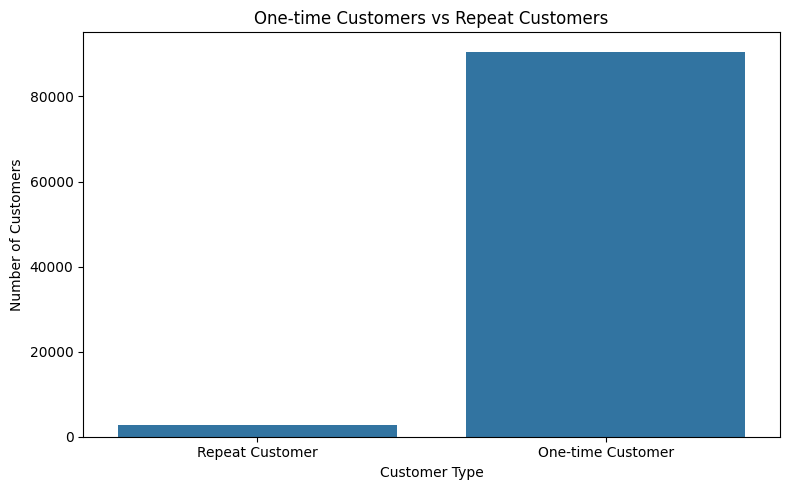

In [35]:
# Plot one-time customers vs repeat customers
plt.figure(figsize=(8, 5))

sns.countplot(
    data=repeat_customers,
    x="customer_type"
)

plt.title("One-time Customers vs Repeat Customers")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [36]:
# Calculate repeat customer percentage
total_customers = repeat_customers["customer_unique_id"].nunique()
number_of_repeat_customers = repeat_customers[
    repeat_customers["number_of_orders"] > 1
]["customer_unique_id"].nunique()

repeat_customer_percentage = (number_of_repeat_customers / total_customers) * 100

print("Total unique customers:", total_customers)
print("Number of repeat customers:", number_of_repeat_customers)
print("Repeat customer percentage:", round(repeat_customer_percentage, 2), "%")

Total unique customers: 93358
Number of repeat customers: 2801
Repeat customer percentage: 3.0 %


repeat customer percentage = repeat customers / total customers × 100

The repeat customer analysis uses `customer_unique_id` instead of `customer_id`, because it better represents the same customer across different orders.

This step is important because using only `customer_id` can incorrectly make most customers look like one-time customers. The repeat customer percentage gives a clearer view of customer retention in the dataset.

In [37]:
from pathlib import Path

# Save cleaned datasets in the processed data folder
processed_folder = Path("../data/processed")
processed_folder.mkdir(parents=True, exist_ok=True)

customers_cleaned.to_csv(processed_folder / "customers_cleaned.csv", index=False)
orders_cleaned.to_csv(processed_folder / "orders_cleaned.csv", index=False)
payments_cleaned.to_csv(processed_folder / "payments_cleaned.csv", index=False)
orders_customers_payments.to_csv(processed_folder / "orders_customers_payments.csv", index=False)
orders_payment_complete.to_csv(processed_folder / "orders_payment_complete.csv", index=False)

print("Cleaned datasets were saved successfully in:", processed_folder)

Cleaned datasets were saved successfully in: ..\data\processed


## 6. Results and Discussion

This section summarizes and interprets the main results of the analysis.

The analysis focused on delivered e-commerce orders and examined product category revenue, average order value over time, payment behavior, and repeat customer behavior.

### Product Category Revenue

The product category revenue analysis showed that total revenue is not equally distributed across product categories.

The top revenue-generating categories include `beleza_saude`, `relogios_presentes`, `cama_mesa_banho`, `esporte_lazer`, and `informatica_acessorios`. These categories generated much higher total revenue than many other categories in the dataset.

This suggests that product category is an important factor for understanding sales performance. Some categories contribute much more strongly to total revenue and may be more important for business strategy, inventory planning, and marketing decisions.

### Average Order Value Over Time

The time-based analysis showed that average order value changes across months. This means that customer spending is not completely stable over time.

The analysis also included the number of delivered orders over time. Looking at both average order value and number of orders is important because a month with a high average order value does not necessarily have the highest total sales volume.

For this reason, the two time-based plots should be interpreted together: one plot shows how much customers spent on average, while the other shows how many delivered orders were placed in each month.

### Payment Behavior

The payment analysis showed that most delivered orders are concentrated in the low and medium order value categories, while high-value orders are less frequent.

The payment summary also showed that higher-value orders have a higher average payment value and a higher average number of installments. This suggests that more expensive orders may involve more complex payment behavior.

The scatter plot between total payment value and number of payment records helps explore whether higher-value orders are associated with more payment records. Overall, payment behavior provides useful information for understanding differences between simple and more complex orders.

### Repeat Customer Behavior

The repeat customer analysis showed that most customers placed only one delivered order.

Using `customer_unique_id` was important because it identifies the same customer across different orders. In contrast, `customer_id` is linked to individual orders and is less suitable for identifying repeat customers.

The results showed:

- Total unique customers: 93,358
- Repeat customers: 2,801
- Repeat customer percentage: 3.0%

This means that repeat customers represent a small part of the customer base in this dataset. Most customers appear as one-time customers.

### Main Insights

The main insights from the analysis are:

1. Revenue is concentrated in a limited number of product categories.
2. Product category is an important factor for understanding sales performance.
3. Average order value changes over time, so sales behavior has a time dimension.
4. Order volume and average order value should be interpreted together.
5. Most orders are low or medium value orders.
6. High-value orders are less frequent but involve higher payment values and more installments.
7. Most customers are one-time customers, while repeat customers represent only a small percentage of the customer base.
8. Repeat customers should be analyzed using `customer_unique_id`, not only `customer_id`.

## 7. Conclusion

This project analyzed delivered e-commerce orders to understand sales performance, product category revenue, payment behavior, and repeat customer behavior.

The analysis showed that product categories, time, and payment information are useful dimensions for understanding e-commerce sales. Some product categories generated much higher revenue than others, average order value changed over time, and payment behavior helped describe differences between lower-value and higher-value orders.

The project also showed that repeat customers should be identified using `customer_unique_id`. Based on this analysis, only a small percentage of customers placed more than one delivered order.

Overall, the project demonstrated how multiple CSV files can be cleaned, merged, aggregated, and visualized in Python to create a complete analytical workflow.

### Answers to the Research Questions

**Main question:**  
How do product categories, time, and payment behavior relate to sales performance in delivered e-commerce orders?

Product categories, time, and payment behavior all provide useful information about sales performance. Product categories show which types of products generate the most revenue. Time-based analysis shows how order value and order volume change across months. Payment behavior helps describe differences between simple and more complex orders.

**Sub-question 1:**  
Which product categories generate the highest total revenue?

The analysis showed that the highest revenue categories include `beleza_saude`, `relogios_presentes`, `cama_mesa_banho`, `esporte_lazer`, and `informatica_acessorios`. This means that total revenue is concentrated in a limited number of product categories.

**Sub-question 2:**  
How does the average order value change over time?

The average order value changes across months. This suggests that customer spending is not completely stable over time, so time is an important dimension for understanding sales patterns.

**Sub-question 3:**  
Is there a relationship between total payment value and the number of payment records per order?

The payment analysis helps check whether higher-value orders are associated with more payment records. It also shows that high-value orders have higher average payment values and higher average installments.

**Sub-question 4:**  
Are there customers who appear more than once in the dataset, and how can repeat orders be identified correctly?

Repeat customers should be identified using `customer_unique_id`, not only `customer_id`. The analysis showed that 2,801 customers placed more than one delivered order, representing about 3.0% of unique customers.

### Limitations

This analysis has some limitations.

First, the project focuses only on delivered orders. This makes the sales analysis cleaner, but it does not explain why some orders were cancelled, unavailable, or not delivered.

Second, the analysis mainly uses descriptive methods. It summarizes and visualizes the data, but it does not build a predictive model.

Third, revenue was analyzed using item price and payment value, but other business factors such as profit margin, marketing cost, seller performance, and customer satisfaction were not included.

Finally, the dataset represents a specific e-commerce context, so the results should not automatically be generalized to all online shopping platforms.

### Future Work

Future analysis could extend this project in several ways.

One possible extension would be to include cancelled and unavailable orders in order to understand incomplete transactions.

Another extension would be to analyze delivery time by comparing estimated delivery dates with actual delivery dates.

The project could also be extended with customer segmentation, for example by grouping customers based on spending level, location, or repeat purchase behavior.

Finally, the cleaned datasets could be used for SQL analysis, allowing the Python results to be compared with SQL aggregation queries.

## 8. Final Check and Export

In this final section, I save the main cleaned and aggregated datasets created during the project.

The raw data files are kept unchanged in the `data/raw` folder. Cleaned and processed datasets are saved separately in the `data/processed` folder to keep the project structure organized and reproducible.

In [38]:
from pathlib import Path

# Define the processed data folder
processed_folder = Path("../data/processed")
processed_folder.mkdir(parents=True, exist_ok=True)

print("Processed data folder is ready:", processed_folder)

Processed data folder is ready: ..\data\processed


In [39]:
# Save cleaned and analytical datasets in the processed data folder

customers_cleaned.to_csv(
    processed_folder / "customers_cleaned.csv",
    index=False
)

orders_cleaned.to_csv(
    processed_folder / "orders_cleaned.csv",
    index=False
)

payments_cleaned.to_csv(
    processed_folder / "payments_cleaned.csv",
    index=False
)

orders_customers_payments.to_csv(
    processed_folder / "orders_customers_payments.csv",
    index=False
)

orders_payment_complete.to_csv(
    processed_folder / "orders_payment_complete.csv",
    index=False
)

product_revenue.to_csv(
    processed_folder / "product_revenue.csv",
    index=False
)

monthly_order_value.to_csv(
    processed_folder / "monthly_order_value.csv",
    index=False
)

repeat_customers.to_csv(
    processed_folder / "repeat_customers.csv",
    index=False
)

print("Final datasets were saved successfully in:", processed_folder)

Final datasets were saved successfully in: ..\data\processed


In [40]:
# Final consistency check for the main analytical datasets

final_datasets = {
    "orders_customers_payments": orders_customers_payments,
    "orders_payment_complete": orders_payment_complete,
    "product_revenue": product_revenue,
    "monthly_order_value": monthly_order_value,
    "payment_behavior_summary": payment_behavior_summary,
    "repeat_customers": repeat_customers
}

for name, df in final_datasets.items():
    print(f"\n{name}")
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])
    print("Duplicated rows:", df.duplicated().sum())


orders_customers_payments
Rows: 96478
Columns: 18
Duplicated rows: 0

orders_payment_complete
Rows: 96477
Columns: 18
Duplicated rows: 0

product_revenue
Rows: 74
Columns: 4
Duplicated rows: 0

monthly_order_value
Rows: 22
Columns: 5
Duplicated rows: 0

payment_behavior_summary
Rows: 3
Columns: 5
Duplicated rows: 0

repeat_customers
Rows: 93358
Columns: 5
Duplicated rows: 0


In [41]:
# Check missing payment values in the payment-complete dataset

orders_payment_complete[
    ["total_payment_value", "number_of_payment_records", "average_installments"]
].isna().sum()

total_payment_value          0
number_of_payment_records    0
average_installments         0
dtype: int64

### Final Project Checklist

Before submitting the notebook, I checked that the project includes:

- a clear introduction
- research questions
- a data dictionary
- data loading from multiple CSV files
- initial exploration with shape, data types, missing values, and duplicates
- filtering of delivered orders
- checking and handling duplicated rows
- date conversion and feature extraction
- aggregation of payment information
- merging of multiple datasets
- at least one custom function
- visualizations for product revenue, time trends, payment behavior, and repeat customers
- discussion of the main results
- conclusion, limitations, and future work
- exported cleaned and aggregated datasets

### Final Project Checklist

Before submitting the notebook, I checked that the project includes:

- a clear introduction
- research questions
- a data dictionary
- data loading from multiple CSV files
- initial exploration with shape, data types, missing values, and duplicates
- filtering of delivered orders
- checking and handling duplicated rows
- date conversion and feature extraction
- aggregation of payment information
- merging of multiple datasets
- at least one custom function
- visualizations for product revenue, time trends, payment behavior, and repeat customers
- discussion of the main results
- conclusion, limitations, and future work
- exported cleaned and aggregated datasets

### Final Summary

This notebook presents a complete Python workflow for analyzing e-commerce data.

The project starts from multiple raw CSV files and creates cleaned and merged analytical datasets. It then uses aggregation and visualization to study product category revenue, average order value over time, payment behavior, and repeat customer behavior.

The final outputs can also be used for SQL analysis and portfolio documentation.

## Statistical Analysis with SciPy

In this section, I use SciPy to add a simple inferential statistics step to the project.

The goal is to test whether there is a statistical relationship between total payment value and the average number of installments.

This is useful because the previous analysis showed payment behavior descriptively. Here, I use correlation to check whether higher-value orders are associated with higher installment numbers.

In [42]:
!pip install scipy


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
# Import SciPy statistics module
from scipy import stats

In [44]:
# Select the relevant payment columns and remove missing values
payment_correlation_data = orders_payment_complete[
    ["total_payment_value", "average_installments"]
].dropna()

# Calculate Pearson correlation
correlation, p_value = stats.pearsonr(
    payment_correlation_data["total_payment_value"],
    payment_correlation_data["average_installments"]
)

print("Pearson correlation:", round(correlation, 4))
print("P-value:", p_value)

Pearson correlation: 0.3178
P-value: 0.0


The Pearson correlation between total payment value and average installments is 0.3178. This indicates a positive but moderate relationship between the two variables.

In other words, higher-value orders tend to have a higher number of installments, although the relationship is not very strong. The p-value is approximately zero, which means that this relationship is statistically significant.

This result supports the idea that more expensive orders may involve more complex payment behavior.

In [45]:
# Calculate a 95% confidence interval for the average order value
aov_data = orders_payment_complete["total_payment_value"].dropna()

mean_aov = aov_data.mean()
sem_aov = stats.sem(aov_data)

confidence_interval = stats.t.interval(
    confidence=0.95,
    df=len(aov_data) - 1,
    loc=mean_aov,
    scale=sem_aov
)

lower_ci = confidence_interval[0]
upper_ci = confidence_interval[1]

print("Mean average order value:", round(mean_aov, 2))
print("95% confidence interval:", round(lower_ci, 2), "to", round(upper_ci, 2))

Mean average order value: 159.86
95% confidence interval: 158.48 to 161.24


The mean average order value is 159.86. The 95% confidence interval is approximately between 158.48 and 161.24.

This means that the estimated average order value is quite stable. Because the dataset contains many delivered orders, the confidence interval is narrow, which suggests that the sample mean is a precise estimate of the average order value in this dataset.

## Simple Machine Learning Model

In this section, I build a simple machine learning model using scikit-learn.

The goal is to predict whether a delivered order is a high-value order or not.

This is a binary classification problem:

- `0` = low or medium value order
- `1` = high value order

This model is only a simple educational example. The main goal is to show how cleaned data can be used for a basic machine learning workflow.

In [46]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
# Import scikit-learn tools for machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [48]:
# Prepare a simple dataset for binary classification
ml_data = orders_payment_complete[
    [
        "total_payment_value",
        "number_of_payment_records",
        "average_installments",
        "purchase_month"
    ]
].dropna().copy()

# Create the target variable: 1 if the order is high-value, 0 otherwise
ml_data["is_high_value"] = (ml_data["total_payment_value"] >= 150).astype(int)

# Define input features and target
X = ml_data[
    [
        "number_of_payment_records",
        "average_installments",
        "purchase_month"
    ]
]

y = ml_data["is_high_value"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print(y.value_counts())

Feature matrix shape: (96477, 3)
Target shape: (96477,)
is_high_value
0    65183
1    31294
Name: count, dtype: int64


In [49]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (77181, 3)
Test set size: (19296, 3)


The dataset was split into a training set and a test set. The training set contains 77,181 observations and the test set contains 19,296 observations.

The model uses three input features: number of payment records, average installments, and purchase month. The 80/20 split allows the model to learn from the training data and then be evaluated on unseen test data.

In [50]:
# Standardize the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = log_reg.predict(X_test_scaled)

In [51]:
# Evaluate the model performance
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7183

Confusion Matrix:
[[12018  1019]
 [ 4417  1842]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.92      0.82     13037
           1       0.64      0.29      0.40      6259

    accuracy                           0.72     19296
   macro avg       0.69      0.61      0.61     19296
weighted avg       0.70      0.72      0.68     19296



The Logistic Regression model achieved an accuracy of 0.7183 on the test set. This means that the model correctly classified about 72% of the test observations.

However, the classification report shows that the model performs better for class `0` than for class `1`. Class `0` represents low or medium value orders, while class `1` represents high-value orders.

For class `1`, the recall is 0.29. This means that the model identifies only a limited part of the actual high-value orders. In other words, many high-value orders are still predicted as non-high-value orders.

Therefore, this model should be interpreted as a simple educational baseline, not as a final predictive model. It demonstrates the basic machine learning workflow: preparing features, splitting data into training and test sets, scaling the features, training a Logistic Regression model, and evaluating the results.

This simple machine learning model shows that payment-related features contain some useful information for predicting high-value orders. However, the low recall for class `1` suggests that additional features, such as product category, customer location, or delivery information, would likely be needed to build a stronger model.

In [52]:
order_items_cleaned.to_csv(
    processed_folder / "order_items_cleaned.csv",
    index=False
)

products_cleaned.to_csv(
    processed_folder / "products_cleaned.csv",
    index=False
)